# Baseline Models - Auto-Urgency Tagging (LEN-05)
1. **Logistic Regression** — cepat, interpretatif, sebagai acuan minimum
2. **Random Forest** — ensemble berbasis pohon, lebih robust terhadap noise

Kedua model dikonfigurasi dengan `class_weight='balanced'` untuk menangani ketidakseimbangan distribusi kelas.


## Cell 1 — Setup Lingkungan & Import Library

In [1]:
import sys
import os

# Deteksi apakah berjalan di Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Jalur absolut menuju direktori root proyek Anda di Drive
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
        
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    # Berjalan secara lokal (VS Code / Jupyter Notebook)
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

# Tambahkan root proyek ke sys.path jika belum terdaftar
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pipeline Rekayasa Fitur (LEN-04, oleh Afif) ---
from src.features import split_data, extract_tfidf

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Styling untuk visualisasi
sns.set_theme(style='whitegrid')
print("Semua library berhasil diimport.")

Mounted at /content/drive
Berjalan di Google Colab. Direktori aktif saat ini: /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research
Semua library berhasil diimport.



## Cell 2 — Load & Validasi Dataset Bersih

In [2]:
# Membaca dataset yang telah melalui proses pembersihan teks (output dari LEN-03)
# Menggunakan os.path.join dengan PROJECT_ROOT agar kompatibel baik secara lokal maupun di Colab.
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Shape awal: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print()

# Validasi: hapus baris dengan nilai kosong pada kolom kunci.
# Kolom `Cleaned_Narrative` adalah input teks dan `Urgency` adalah target label.
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape setelah dropna: {df.shape}")
print()

# Cek distribusi kelas untuk memahami tingkat ketidakseimbangan dataset
print("Distribusi kelas Urgency:")
print(df['Urgency'].value_counts())

Dataset berhasil dimuat. Shape awal: (53927, 3)
Kolom tersedia: ['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']

Shape setelah dropna: (53927, 3)

Distribusi kelas Urgency:
Urgency
Medium    26299
High      20771
Low        6857
Name: count, dtype: int64



## Cell 3 — Visualisasi Distribusi Kelas

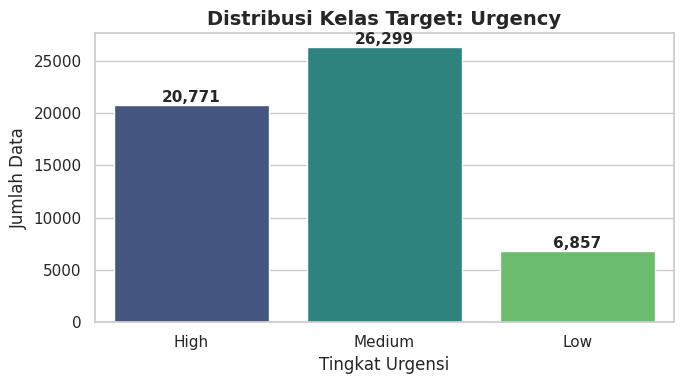

In [3]:
# Memvisualisasikan distribusi kelas target untuk mengkonfirmasi adanya
# ketidakseimbangan kelas (class imbalance) yang menjadi dasar penggunaan
# parameter `class_weight='balanced'` pada model.
order = ['High', 'Medium', 'Low']
counts = df['Urgency'].value_counts().reindex(order)

plt.figure(figsize=(7, 4))
bars = sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)

for bar in bars.patches:
    bars.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Distribusi Kelas Target: Urgency', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Urgensi')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()


## Cell 4 — Data Splitting (Pipeline LEN-04)

In [4]:
# Memanggil fungsi `split_data()` dari pipeline LEN-04 (src/features.py).
# Fungsi ini membagi dataset secara stratified dengan rasio:
#   - Train  : 70%
#   - Val    : 15%
#   - Test   : 15%
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

# Ekstrak label target (y) dari masing-masing split DataFrame
y_train = df_train['Urgency']
y_val   = df_val['Urgency']
y_test  = df_test['Urgency']

print("\nDistribusi kelas pada setiap split:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: {y.value_counts().to_dict()}")

Train size: 37748, Val size: 8089, Test size: 8090

Distribusi kelas pada setiap split:
  Train: {'Medium': 18409, 'High': 14539, 'Low': 4800}
  Val: {'Medium': 3945, 'High': 3116, 'Low': 1028}
  Test: {'Medium': 3945, 'High': 3116, 'Low': 1029}



## Cell 5 — Ekstraksi Fitur TF-IDF (Pipeline LEN-04)

In [5]:
# Memanggil fungsi `extract_tfidf()` dari pipeline LEN-04 (src/features.py).
# data leakage, lalu mentransformasi data val dan test menggunakan vocabulari
X_train_tfidf, X_val_tfidf, X_test_tfidf, tfidf_vectorizer = extract_tfidf(
    train_texts=df_train['Cleaned_Narrative'],
    val_texts=df_val['Cleaned_Narrative'],
    test_texts=df_test['Cleaned_Narrative']
)

print(f"Shape fitur TF-IDF:")
print(f"  X_train : {X_train_tfidf.shape}")
print(f"  X_val   : {X_val_tfidf.shape}")
print(f"  X_test  : {X_test_tfidf.shape}")
print(f"\nUkuran vocabulary TF-IDF: {len(tfidf_vectorizer.vocabulary_)} kata")

Shape fitur TF-IDF:
  X_train : (37748, 5000)
  X_val   : (8089, 5000)
  X_test  : (8090, 5000)

Ukuran vocabulary TF-IDF: 5000 kata



## Cell 6 — Model 1: Logistic Regression

In [6]:
# --- PELATIHAN: Logistic Regression ---
# Logistic Regression dipilih sebagai baseline minimum yang cepat dan interpretatif.
# Parameter penting:
#   - class_weight='balanced'  : mengkompensasi ketidakseimbangan kelas secara otomatis
#                                dengan menaikkan bobot pada kelas minoritas.
#   - max_iter=1000            : iterasi lebih banyak agar model konvergen pada data besar.
#   - random_state=42          : reproducibility hasil.
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print("Melatih Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
print("Pelatihan selesai.")

Melatih Logistic Regression...
Pelatihan selesai.



## Cell 7 — Evaluasi Logistic Regression pada Test Set

In [19]:
# Melakukan prediksi pada test set menggunakan model Logistic Regression
# yang telah dilatih. Test set bersifat held-out dan TIDAK pernah dilihat model
y_pred_lr = lr_model.predict(X_test_tfidf)

print("  EVALUASI MODEL 1: Logistic Regression (Test Set)")

# Classification Report menampilkan Precision, Recall, F1-Score per kelas
# serta rata-rata macro dan weighted — metrik utama untuk dataset imbalanced.
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['High', 'Medium', 'Low']
))

  EVALUASI MODEL 1: Logistic Regression (Test Set)
              precision    recall  f1-score   support

        High       0.89      0.79      0.84      3116
      Medium       0.50      0.88      0.64      1029
         Low       0.86      0.76      0.80      3945

    accuracy                           0.79      8090
   macro avg       0.75      0.81      0.76      8090
weighted avg       0.82      0.79      0.80      8090




## Cell 8 — Confusion Matrix Logistic Regression

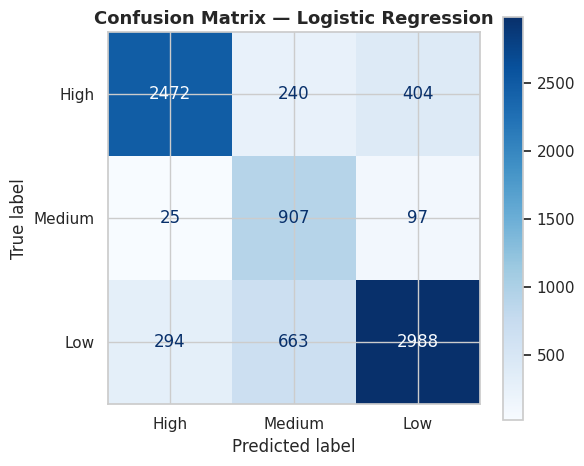

In [8]:
# Visualisasi Confusion Matrix untuk melihat pola kesalahan prediksi
# antar kelas secara lebih intuitif.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=['High', 'Medium', 'Low'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 9 — Model 2: Random Forest

In [14]:
# --- PELATIHAN: Random Forest ---
# Random Forest adalah model ensemble yang lebih kompleks dan umumnya lebih
# robust terhadap noise dibandingkan Logistic Regression.
# Parameter penting:
#   - n_estimators=200         : jumlah pohon keputusan dalam ensemble.
#   - class_weight='balanced'  : penanganan class imbalance (wajib, sama seperti LR).
#   - n_jobs=-1                : memanfaatkan seluruh core CPU untuk mempercepat pelatihan.
#   - random_state=42          : reproducibility hasil.
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Melatih Random Forest (200 trees)")
rf_model.fit(X_train_tfidf, y_train)
print("Pelatihan selesai.")

Melatih Random Forest (200 trees)
Pelatihan selesai.



## Cell 10 — Evaluasi Random Forest pada Test Set

In [15]:
# Melakukan prediksi pada test set menggunakan model Random Forest
y_pred_rf = rf_model.predict(X_test_tfidf)

print("  EVALUASI MODEL 2: Random Forest (Test Set)")

# Classification Report: Precision, Recall, F1-Score per kelas
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['High', 'Medium', 'Low']
))

  EVALUASI MODEL 2: Random Forest (Test Set)
              precision    recall  f1-score   support

        High       0.91      0.82      0.86      3116
      Medium       0.73      0.58      0.64      1029
         Low       0.80      0.91      0.85      3945

    accuracy                           0.83      8090
   macro avg       0.82      0.77      0.79      8090
weighted avg       0.84      0.83      0.83      8090




## Cell 11 — Confusion Matrix Random Forest

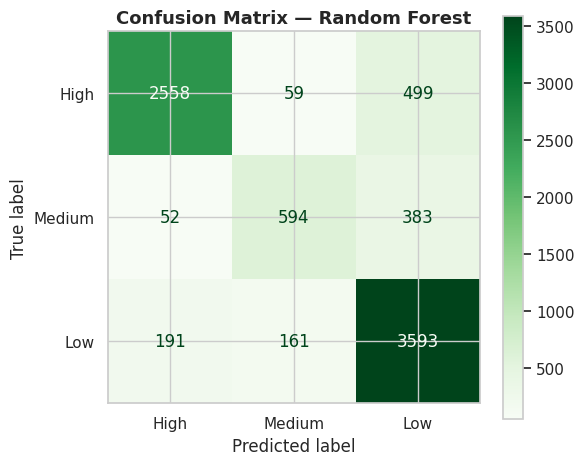

In [16]:
# Visualisasi Confusion Matrix untuk Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['High', 'Medium', 'Low'],
    cmap='Greens',
    ax=ax
)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Cell 12 — Perbandingan Performa Kedua Model (Ringkasan)

In [17]:
from sklearn.metrics import f1_score, accuracy_score

# Membuat tabel ringkasan perbandingan metrik utama kedua model
# untuk memudahkan pengambilan keputusan model mana yang akan
# digunakan lebih lanjut (handoff ke tim evaluasi - LEN-09).
results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score Macro': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'F1-Score Weighted': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
}

df_results = pd.DataFrame(results)

df_results[['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']] = \
    df_results[['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']].map(lambda x: f'{x:.4f}')

print("  RINGKASAN PERBANDINGAN PERFORMA MODEL BASELINE")
print(df_results.to_string(index=False))
print()
print("Catatan: F1-Score Macro diprioritaskan sebagai metrik utama")
print("         karena dataset memiliki ketidakseimbangan kelas.")

  RINGKASAN PERBANDINGAN PERFORMA MODEL BASELINE
              Model Accuracy F1-Score Macro F1-Score Weighted
Logistic Regression   0.7870         0.7599            0.7956
      Random Forest   0.8337         0.7876            0.8312

Catatan: F1-Score Macro diprioritaskan sebagai metrik utama
         karena dataset memiliki ketidakseimbangan kelas.



## Cell 13 — Visualisasi Perbandingan F1-Score per Kelas

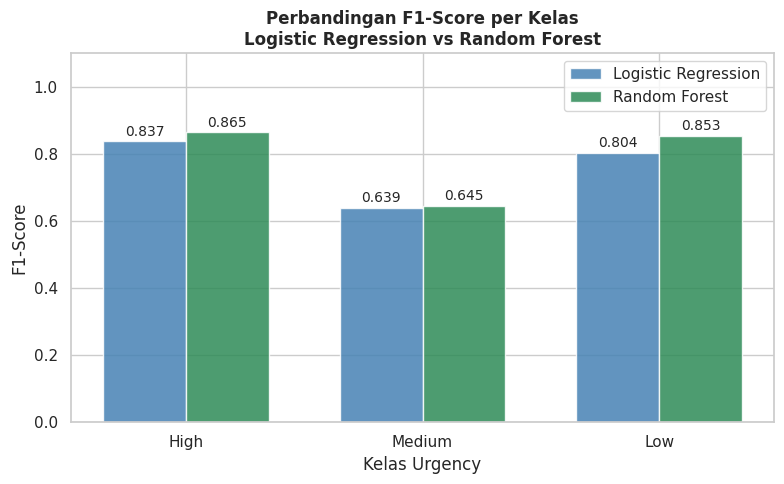

In [18]:
from sklearn.metrics import classification_report

# Mengekstrak F1-Score per kelas dari kedua model untuk visualisasi
# perbandingan side-by-side yang lebih mudah dibaca.
classes = ['High', 'Medium', 'Low']

report_lr = classification_report(y_test, y_pred_lr, target_names=classes, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=classes, output_dict=True)

f1_lr = [report_lr[c]['f1-score'] for c in classes]
f1_rf = [report_rf[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, f1_lr, width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_rf, width, label='Random Forest', color='seagreen', alpha=0.85)

# Tambahkan nilai di atas setiap bar
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

ax.set_xlabel('Kelas Urgency')
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score per Kelas\nLogistic Regression vs Random Forest', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()